# Mini GPT-2 From Scratch


## 1. Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

PyTorch: 2.11.0+cu128
Device: cuda


## 2. Download & Load Dataset


In [2]:
!wget -q https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r') as f:
    text = f.read()
print(f"Total characters: {len(text):,}")
print("Sample:\n", text[:300])

Total characters: 1,115,394
Sample:
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


## 3. Tokenizer — Character Level

In [3]:
chars = sorted(set(text))
vocab_size = len(chars)
print(f"Vocab size: {vocab_size}")
print(f"Characters: {''.join(chars)}")

stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for i, c in enumerate(chars)}

encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

Vocab size: 65
Characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


## 4. Train / Val Split

In [4]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data   = data[n:]
print(f"Train tokens: {len(train_data):,}")
print(f"Val tokens  : {len(val_data):,}")

Train tokens: 1,003,854
Val tokens  : 111,540


## 5. Hyperparameters


In [31]:
batch_size    = 32
block_size    = 128
max_iters     = 7000
eval_interval = 300
eval_iters    = 100
learning_rate = 1e-3
n_embd        = 256
n_head        = 8
n_layer       = 8
dropout       = 0.1

## 6. Data Loader

In [32]:
def get_batch(split):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x  = torch.stack([d[i:i+block_size]   for i in ix])
    y  = torch.stack([d[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

## 7. Loss Estimation

In [33]:
@torch.no_grad()
def estimate_loss(model):
    model.eval()
    losses = {}
    for split in ['train', 'val']:
        L = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            L[k] = loss.item()
        losses[split] = L.mean().item()
    model.train()
    return losses

## 8. Model Architecture

### 8.1 Single Self-Attention Head

In [34]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2, -1) * C**-0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        return wei @ v

### 8.2 Multi-Head Attention

In [35]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads   = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj    = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))

### 8.3 Feed Forward Block

In [36]:
class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

### 8.4 Transformer Block

In [37]:
class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa   = MultiHeadAttention(n_head, head_size)
        self.ff   = FeedForward(n_embd)
        self.ln1  = nn.LayerNorm(n_embd)
        self.ln2  = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

### 8.5 GPT Language Model

In [38]:
class GPTLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table    = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks   = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_final = nn.LayerNorm(n_embd)
        self.lm_head  = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x    = tok_emb + pos_emb
        x    = self.blocks(x)
        x    = self.ln_final(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs  = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

## 9. Initialise Model

In [39]:
model = GPTLanguageModel().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 6,378,561


## 10. Training Loop

In [40]:
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

train_losses, val_losses, steps = [], [], []

for step in range(max_iters):
    if step % eval_interval == 0:
        loss_dict = estimate_loss(model)
        train_losses.append(loss_dict['train'])
        val_losses.append(loss_dict['val'])
        steps.append(step)
        print(f"Step {step:4d} | train loss {loss_dict['train']:.4f} | val loss {loss_dict['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f"\nFinal step | train loss {train_losses[-1]:.4f} | val loss {val_losses[-1]:.4f}")

Step    0 | train loss 4.3038 | val loss 4.3083
Step  300 | train loss 2.0998 | val loss 2.1566
Step  600 | train loss 1.7100 | val loss 1.8593
Step  900 | train loss 1.5476 | val loss 1.7185
Step 1200 | train loss 1.4554 | val loss 1.6417
Step 1500 | train loss 1.3967 | val loss 1.6003
Step 1800 | train loss 1.3497 | val loss 1.5654
Step 2100 | train loss 1.3182 | val loss 1.5512
Step 2400 | train loss 1.2939 | val loss 1.5349
Step 2700 | train loss 1.2694 | val loss 1.5200
Step 3000 | train loss 1.2418 | val loss 1.5229
Step 3300 | train loss 1.2275 | val loss 1.5098
Step 3600 | train loss 1.2040 | val loss 1.5026
Step 3900 | train loss 1.1916 | val loss 1.4998
Step 4200 | train loss 1.1729 | val loss 1.5135
Step 4500 | train loss 1.1587 | val loss 1.4979
Step 4800 | train loss 1.1400 | val loss 1.4996
Step 5100 | train loss 1.1243 | val loss 1.4991
Step 5400 | train loss 1.1148 | val loss 1.5192
Step 5700 | train loss 1.0969 | val loss 1.5069
Step 6000 | train loss 1.0841 | val loss

## 11. Loss Curves

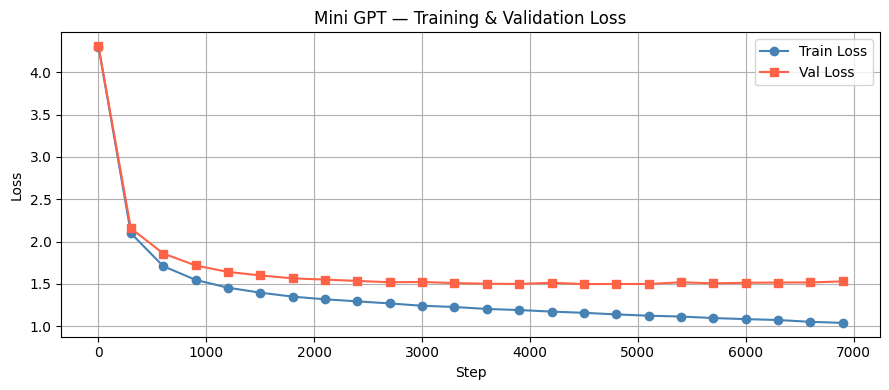

In [41]:
plt.figure(figsize=(9, 4))
plt.plot(steps, train_losses, label='Train Loss', color='steelblue', marker='o')
plt.plot(steps, val_losses,   label='Val Loss',   color='tomato',    marker='s')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Mini GPT — Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 12. Generate Text

In [42]:
model.eval()
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated = model.generate(context, max_new_tokens=300)
print(decode(generated[0].tolist()))


Ay, backlupting fools,
There and their states speed, leaving me bearer:
I cannot be give a clogy to see
What I send this way to lay my uncle,
I'll import it with thee, and well withnough thy legs.

QUEEN MARGARET:
But I'll give an idle mine enemy, if break, proud all the volume
Which to endure I wit


In [43]:
seed_text = "ROMEO:"
context   = torch.tensor([encode(seed_text)], dtype=torch.long, device=device)
generated = model.generate(context, max_new_tokens=300)
print(decode(generated[0].tolist()))

ROMEO:
Have I right the ship of York.

DUKE VINCENTIO:
I grant this indication,
Is not fall'n the danger out thereof, look both:
I can no longer delicious voice once upon hold,
That deshouts when he will feel this perish traitor:
His own prushing with doing, and joy company,
But see how he is a lussey pit
